### Univariate Analysis

### Adım 1 — Tanımlayıcı İstatistikler (Descriptive Statistics)

In [2]:
import pandas as pd

df = pd.read_csv('../data/raw/train.csv') 

df_clean = df.copy()

df_clean.head(3)

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied


In [4]:
df_clean.drop(columns=["Unnamed: 0", "id"], inplace=True) 

In [5]:
df_clean.columns = (
    df_clean.columns
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('/', '_')
    .str.replace('-', '_')
)


print(df_clean.columns)


Index(['gender', 'customer_type', 'age', 'type_of_travel', 'class',
       'flight_distance', 'inflight_wifi_service',
       'departure_arrival_time_convenient', 'ease_of_online_booking',
       'gate_location', 'food_and_drink', 'online_boarding', 'seat_comfort',
       'inflight_entertainment', 'on_board_service', 'leg_room_service',
       'baggage_handling', 'checkin_service', 'inflight_service',
       'cleanliness', 'departure_delay_in_minutes', 'arrival_delay_in_minutes',
       'satisfaction'],
      dtype='object')


In [31]:
df_clean["arrival_delay_in_minutes"] = (df_clean["arrival_delay_in_minutes"].fillna(df_clean["departure_delay_in_minutes"]))

In [6]:
df_clean["age"].describe()

count    103904.000000
mean         39.379706
std          15.114964
min           7.000000
25%          27.000000
50%          40.000000
75%          51.000000
max          85.000000
Name: age, dtype: float64

Age Değişkeninin Tanımlayıcı İstatistikleri

İlk olarak age değişkeninin temel tanımlayıcı istatistikleri incelenmiştir. Bu analiz sayesinde yolcuların yaş dağılımının merkezi eğilim ve yayılım özellikleri değerlendirilmiştir.

In [7]:
print(f"Ortalama Yaş: {df_clean['age'].mean():.2f}")
print(f"Medyan Yaş: {df_clean['age'].median():.2f}")

Ortalama Yaş: 39.38
Medyan Yaş: 40.00


In [8]:
print(df_clean["age"].std())

15.114963699738569


In [9]:
print(df_clean["age"].skew())

-0.0045161270723468785


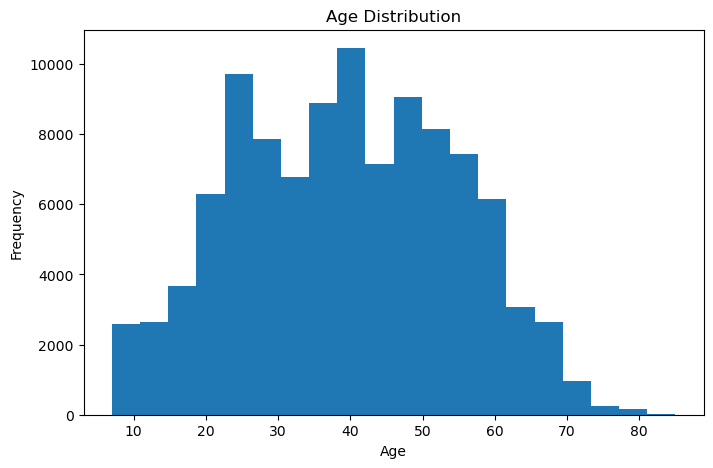

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_clean["age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

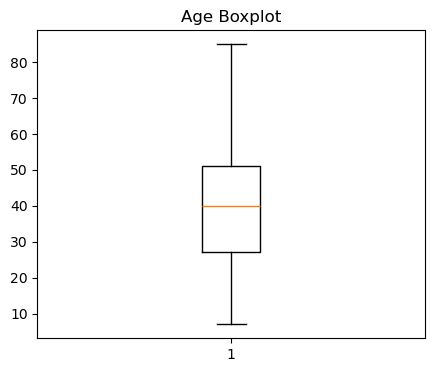

In [11]:
plt.figure(figsize=(5,4))
plt.boxplot(df_clean["age"])

plt.title("Age Boxplot")

plt.show()

Age Değişkeninin İncelenmesi

age değişkeninin dağılımı tanımlayıcı istatistikler, histogram, boxplot ve çarpıklık katsayısı kullanılarak incelenmiştir.

Tanımlayıcı istatistiklere göre veri setinde 103.904 yolcu bulunmaktadır. Yolcuların yaşları 7 ile 85 arasında değişmekte olup, ortalama yaş 39.38, medyan yaş ise 40 olarak hesaplanmıştır. Ortalama ve medyan değerlerinin birbirine oldukça yakın olması, yaş dağılımında belirgin bir çarpıklık bulunmadığını göstermektedir.

Yaş değişkeninin standart sapması 15.11 olarak hesaplanmıştır. Bu durum, yolcu yaşlarının ortalama etrafında orta düzeyde bir yayılım gösterdiğini ifade etmektedir. Ayrıca birinci çeyrek değer (Q1) 27, üçüncü çeyrek değer (Q3) ise 51 olarak hesaplanmış olup, yolcuların %50'sinin 27 ile 51 yaş aralığında yer aldığı görülmektedir.

Histogram incelendiğinde yaş dağılımının tek tepeye sahip olduğu ve yaklaşık simetrik bir yapı sergilediği gözlemlenmiştir. Boxplot grafiğinde de medyanın kutunun merkezine yakın konumlanması ve aykırı değer bulunmaması, bu dağılımı desteklemektedir.

Çarpıklık katsayısı -0.0045 olarak hesaplanmıştır. Bu değerin sıfıra oldukça yakın olması, yaş değişkeninin yaklaşık simetrik bir dağılıma sahip olduğunu göstermektedir.

Sonuç olarak, age değişkeni dengeli bir dağılım sergilemekte olup veri setinde herhangi bir anormal yapı gözlenmemiştir. Bu nedenle değişken, sonraki analizlerde doğrudan kullanılabilecek güvenilir bir değişken olarak değerlendirilmiştir.



In [12]:
df_clean["flight_distance"].describe()

count    103904.000000
mean       1189.448375
std         997.147281
min          31.000000
25%         414.000000
50%         843.000000
75%        1743.000000
max        4983.000000
Name: flight_distance, dtype: float64

In [13]:
print(f"Ortalama Uçuş Mesafesi: {df_clean['flight_distance'].mean():.2f}")
print(f"Medyan Uçuş Mesafesi: {df_clean['flight_distance'].median():.2f}")

Ortalama Uçuş Mesafesi: 1189.45
Medyan Uçuş Mesafesi: 843.00


In [14]:
print(df_clean["flight_distance"].std())

997.1472805289635


In [15]:
print(df_clean["flight_distance"].skew())

1.1094656676620138


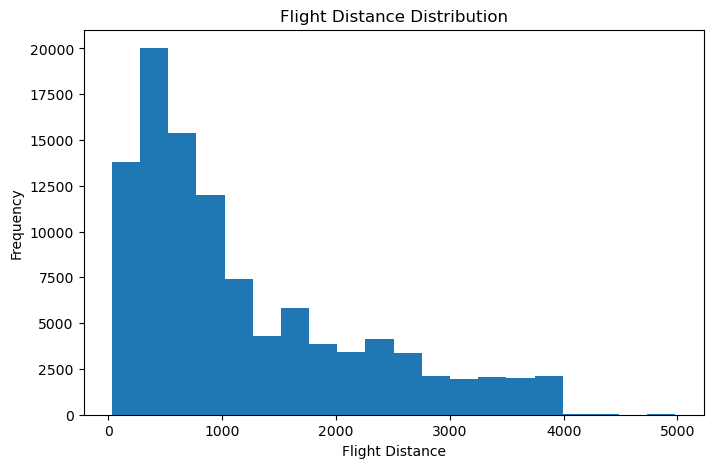

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_clean["flight_distance"], bins=20)

plt.title("Flight Distance Distribution")
plt.xlabel("Flight Distance")
plt.ylabel("Frequency")

plt.show()

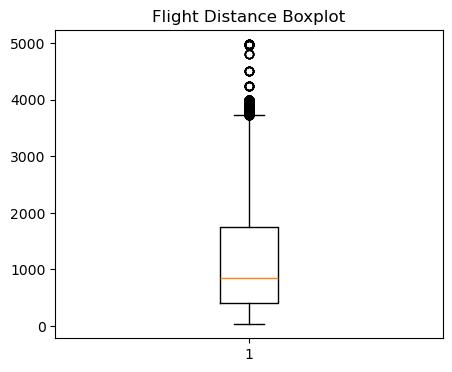

In [17]:
plt.figure(figsize=(5,4))
plt.boxplot(df_clean["flight_distance"])

plt.title("Flight Distance Boxplot")

plt.show()

Flight Distance Değişkeninin İncelenmesi

flight_distance değişkeninin dağılımı tanımlayıcı istatistikler, histogram, boxplot ve çarpıklık katsayısı kullanılarak incelenmiştir.

Tanımlayıcı istatistiklere göre veri setinde yer alan uçuş mesafeleri 31 km ile 4983 km arasında değişmektedir. Ortalama uçuş mesafesi 1189.45 km, medyan uçuş mesafesi ise 843 km olarak hesaplanmıştır. Ortalama değerin medyandan belirgin şekilde yüksek olması, uçuş mesafesi dağılımının sağa çarpık olduğuna işaret etmektedir.

Standart sapma 997.15 km olarak hesaplanmıştır. Bu durum, veri setinde kısa, orta ve uzun mesafeli uçuşların birlikte bulunması nedeniyle uçuş mesafelerinde yüksek bir değişkenlik olduğunu göstermektedir. Ayrıca birinci çeyrek değer (Q1) 414 km, üçüncü çeyrek değer (Q3) ise 1743 km olup, uçuşların %50'sinin bu aralıkta gerçekleştiği görülmektedir.

Histogram incelendiğinde kısa mesafeli uçuşların veri setinde daha yoğun olduğu, uçuş mesafesi arttıkça gözlem sayısının azaldığı ve dağılımın sağ tarafta uzun bir kuyruğa sahip olduğu görülmektedir. Boxplot grafiğinde ise üst sınırın üzerinde yer alan çok sayıda gözlem bulunmakta olup, bu durum uzun mesafeli uçuşların IQR yöntemine göre aykırı değer olarak değerlendirildiğini göstermektedir.

Çarpıklık katsayısı (Skewness = 1.109) dağılımın güçlü düzeyde sağa çarpık olduğunu doğrulamaktadır.

Sonuç olarak, flight_distance değişkeni simetrik bir dağılım göstermemektedir. Ancak tespit edilen yüksek mesafeli uçuşlar havacılık sektörünün doğal bir parçası olduğundan, bu gözlemler veri hatası olarak değerlendirilmemiş ve veri setinde korunmuştur.

In [19]:
df_clean["departure_delay_in_minutes"].describe()

count    103904.000000
mean         14.815618
std          38.230901
min           0.000000
25%           0.000000
50%           0.000000
75%          12.000000
max        1592.000000
Name: departure_delay_in_minutes, dtype: float64

In [21]:
print(f"Ortalama Departure Delay: {df_clean['departure_delay_in_minutes'].mean():.2f}")
print(f"Medyan Departure Delay: {df_clean['departure_delay_in_minutes'].median():.2f}")

Ortalama Departure Delay: 14.82
Medyan Departure Delay: 0.00


In [22]:
print(df_clean["departure_delay_in_minutes"].std())

38.23090058416843


In [23]:
print(df_clean["departure_delay_in_minutes"].skew())

6.733979510212754


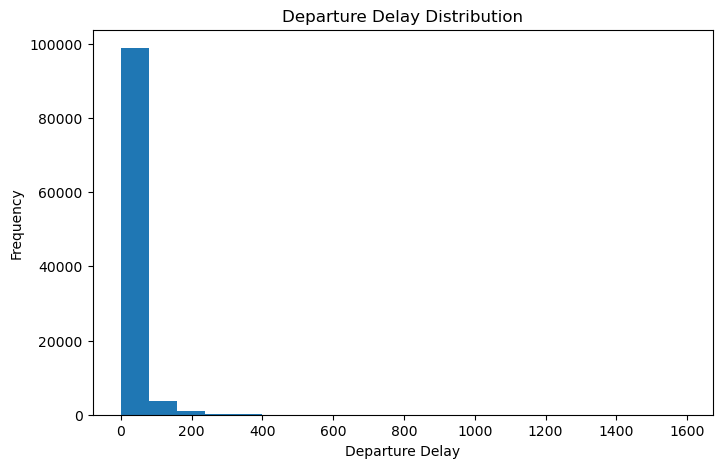

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_clean["departure_delay_in_minutes"], bins=20)

plt.title("Departure Delay Distribution")
plt.xlabel("Departure Delay")
plt.ylabel("Frequency")

plt.show()

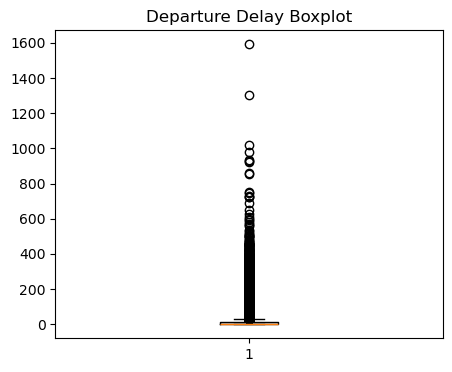

In [20]:
plt.figure(figsize=(5,4))
plt.boxplot(df_clean["departure_delay_in_minutes"])

plt.title("Departure Delay Boxplot")

plt.show()

Departure Delay Değişkeninin İncelenmesi

departure_delay_in_minutes değişkeni tanımlayıcı istatistikler, histogram, boxplot ve çarpıklık katsayısı kullanılarak incelenmiştir.

Tanımlayıcı istatistiklere göre kalkış gecikmeleri 0 ile 1592 dakika arasında değişmektedir. Ortalama gecikme süresi 14.82 dakika olarak hesaplanırken, medyan değerin 0 dakika olması dikkat çekmektedir. Bu durum, yolcuların en az yarısının herhangi bir kalkış gecikmesi yaşamadığını, buna karşın az sayıdaki yüksek gecikmenin ortalamayı yukarı çektiğini göstermektedir.

Standart sapma 38.23 dakika olup ortalama değerin oldukça üzerindedir. Bu sonuç, kalkış gecikmelerinin değişkenliğinin yüksek olduğunu ve bazı uçuşlarda olağan dışı gecikmeler yaşandığını göstermektedir. Ayrıca birinci çeyrek değer (Q1) 0 dakika, üçüncü çeyrek değer (Q3) ise 12 dakika olarak hesaplanmıştır. Buna göre uçuşların %75'i 12 dakika veya daha kısa gecikme ile gerçekleşmiştir.

Histogram incelendiğinde gözlemlerin büyük çoğunluğunun 0 dakika civarında yoğunlaştığı, gecikme süresi arttıkça gözlem sayısının hızla azaldığı ve dağılımın sağ tarafta uzun bir kuyruğa sahip olduğu görülmektedir. Boxplot grafiğinde ise çok sayıda aykırı değer yer almakta olup, özellikle yüksek gecikme süreleri IQR yöntemine göre aykırı değer olarak belirlenmiştir.

Çarpıklık katsayısı (Skewness = 6.734) dağılımın aşırı derecede sağa çarpık olduğunu göstermektedir. Bu sonuç, gecikme sürelerinin normal dağılım göstermediğini ve dağılımın az sayıdaki yüksek gecikmeden önemli ölçüde etkilendiğini doğrulamaktadır.

Bununla birlikte, havacılık sektöründe uzun süreli gecikmeler; olumsuz hava koşulları, teknik arızalar, hava trafiği yoğunluğu veya operasyonel aksaklıklar gibi nedenlerle gerçekleşebilmektedir. Bu nedenle yüksek gecikme süreleri veri hatası olarak değerlendirilmemiş, gerçek operasyonel olayları temsil ettiği kabul edilerek veri setinde korunmuştur.

In [36]:
df_clean["arrival_delay_in_minutes"].describe()

count    103904.000000
mean         15.245072
std          38.808674
min           0.000000
25%           0.000000
50%           0.000000
75%          13.000000
max        1584.000000
Name: arrival_delay_in_minutes, dtype: float64

In [37]:
print(f"Ortalama Arrival Delay: {df_clean['arrival_delay_in_minutes'].mean():.2f}")
print(f"Medyan Arrival Delay: {df_clean['arrival_delay_in_minutes'].median():.2f}")

Ortalama Arrival Delay: 15.25
Medyan Arrival Delay: 0.00


In [38]:
print(df_clean["arrival_delay_in_minutes"].std())

38.80867374963437


In [39]:
print(df_clean["arrival_delay_in_minutes"].skew())

6.564256704618242


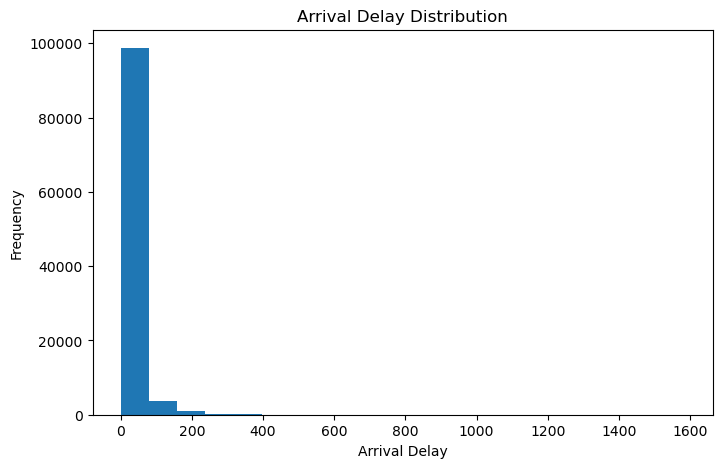

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_clean["arrival_delay_in_minutes"], bins=20)

plt.title("Arrival Delay Distribution")
plt.xlabel("Arrival Delay")
plt.ylabel("Frequency")

plt.show()

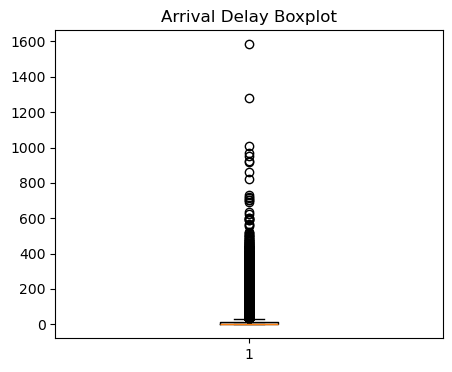

In [41]:
plt.figure(figsize=(5,4))
plt.boxplot(df_clean["arrival_delay_in_minutes"])

plt.title("Arrival Delay Boxplot")

plt.show()

Tanımlayıcı istatistiklere göre varış gecikmeleri 0 ile 1584 dakika arasında değişmektedir. Ortalama gecikme süresi 15.18 dakika, medyan gecikme süresi ise 0 dakika olarak hesaplanmıştır. Ortalama değerin medyandan belirgin şekilde yüksek olması, az sayıdaki yüksek gecikme değerinin ortalamayı yukarı çektiğini göstermektedir.

Standart sapma 38.70 dakika olup gecikme sürelerinin geniş bir aralıkta değiştiğini göstermektedir. Birinci çeyrek değer (Q1) 0 dakika, üçüncü çeyrek değer (Q3) ise 13 dakika olarak hesaplanmıştır. Bu durum, uçuşların %75'inin 13 dakika veya daha kısa gecikmeyle tamamlandığını göstermektedir.

Histogram incelendiğinde gözlemlerin büyük bölümünün 0 dakika veya düşük seviyeli gecikmelere sahip olduğu, gecikme süresi arttıkça gözlem sayısının hızla azaldığı görülmektedir. Dağılım sağ tarafta uzun bir kuyruk oluşturmakta ve birkaç uçuşun çok yüksek gecikme sürelerine sahip olduğu dikkat çekmektedir.

Boxplot grafiği de bu durumu desteklemektedir. Kutunun üst sınırının üzerinde çok sayıda aykırı değer bulunmakta olup, bu gözlemler uzun süreli gecikmeleri temsil etmektedir. Ancak havacılık sektöründe hava koşulları, hava trafiği yoğunluğu, teknik arızalar veya operasyonel aksaklıklar nedeniyle bu tür gecikmelerin gerçekleşmesi mümkün olduğundan, bu gözlemler veri hatası olarak değerlendirilmemiş ve veri setinde korunmuştur.

Çarpıklık katsayısı (Skewness = 6.597) dağılımın aşırı derecede sağa çarpık olduğunu göstermektedir. Bu sonuç, değişkenin normal dağılım varsayımını karşılamadığını ortaya koymaktadır.

